In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import math

In [2]:
redwine = pd.read_csv('winequality-red.csv', sep=",")
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
#Q1
redwine['quality'] = np.where(redwine['quality'] > 6.5, 'good', 'bad')
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,bad
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [4]:
X=redwine.drop('quality',axis=1)
y=redwine['quality']

In [5]:
xname = X.columns
yname = ['bad','good']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2039, stratify=y)

In [7]:
p=X.shape[1]
p

11

In [8]:
#Q3
# max_depth: 2 ~ 14, 간격 2 (14 포함)
max_depth_range = list(range(2, 15, 2))

# n_estimators: 100 고정
n_estimators_val=100


# max_features: p의 10%~100%, 10% 간격 (floor 적용) 
max_features_range = [math.floor(i*0.1*p) for i in range(1, 11)]


#Q4
results = []
model_idx = 1

for md in max_depth_range:          
    for mf in max_features_range:              
        
        rfc = RandomForestClassifier(
            max_depth = md,
            n_estimators = n_estimators_val,
            max_features = mf,
            random_state=2039
        )

        # Training 데이터로 학습
        rfc.fit(X_train, y_train)

        # Validation 데이터로 예측 확률 추출 
        y_prob = rfc.predict_proba(X_test)[:, list(rfc.classes_).index('good')]
        # Validation 데이터로 예측 정확도 
        auroc  = roc_auc_score((y_test == 'good').astype(int), y_prob)

        results.append({
            "model_no"  : model_idx,
            "max_depth" : md,
            "max_features" : mf,
            "AUROC"             : auroc
        })
        model_idx=model_idx+1


# 결과
results_df = pd.DataFrame(results)
results_df

,model_no,max_depth,max_features,AUROC
0,1,2,1,0.857924
1,2,2,2,0.863394
2,3,2,3,0.865924
3,4,2,4,0.860095
4,5,2,5,0.866428
...,...,...,...,...
65,66,14,6,0.900516
66,67,14,7,0.896148
67,68,14,8,0.891435
68,69,14,9,0.895465


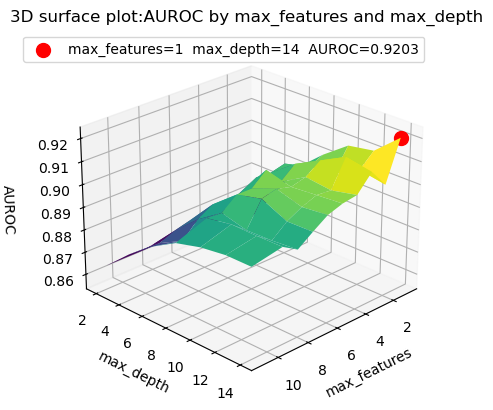

In [9]:
#Q5
pivot = results_df.pivot(index='max_depth', columns='max_features', values='AUROC')

X_mesh, Y_mesh = np.meshgrid(pivot.columns.values, pivot.index.values)


fig, ax  = plt.subplots(subplot_kw={"projection":"3d"})
ax.plot_surface(X_mesh, Y_mesh, pivot.values, cmap=cm.viridis)

# 최적값 점
best = results_df.loc[results_df['AUROC'].idxmax()]
ax.scatter(best['max_features'], best['max_depth'], best['AUROC'],
           color='red', s=100,
           label=f"max_features={int(best['max_features'])}  max_depth={int(best['max_depth'])}  AUROC={best['AUROC']:.4f}")
ax.legend()
ax.view_init(elev=25, azim=45) 
ax.set_xlabel('max_features')  # X축 = max_features
ax.set_ylabel('max_depth')  # Y축 = max_depth
ax.set_zlabel('AUROC',labelpad=10)
ax.set_title('3D surface plot:AUROC by max_features and max_depth')

plt.show()

In [10]:
result = results_df.loc[results_df['AUROC'].idxmax()]
print(result)

model_no        61.000000
max_depth       14.000000
max_features     1.000000
AUROC            0.920345
Name: 60, dtype: float64


In [12]:
#Q6 결과

#최적 하이퍼파라미터는 max_depth=14, max_features=1이며, 이때 AUROC=0.9203으로 가장 높았다.

#max_depth=14: RandomForest는 앙상블 구조로 과적합이 억제되므로, 탐색 범위 내에서 트리가 깊을수록 AUROC가 단조 증가하는 경향을 보였다.
  
#max_features=1: 각 분기에서 1개의 특성만 사용하여 트리 간 다양성이 극대화되고 상관관계가 낮아져 앙상블 효과가 가장 크게 발휘되었다.